# EDA for Scalability of System based on Number of Users
### Load the final results CSV file from the simulator

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set professional aesthetics for the FYP report
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Load the RAW dataset (where the actual dB and Mbps values live)
file_path = '../data/raw/simulation_data.csv'
print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path)

# 2. Group the data by the number of users and calculate the mean for the physical parameters
print("Calculating averages across user loads...")
grouped_data = df.groupby('num_interferers')[['sinr_d2d_db', 'sinr_cell_db', 
                                              'throughput_d2d_mbps', 'throughput_cell_mbps', 
                                              'interference_dbm']].mean().reset_index()

# Ensure the results directory exists
save_dir = '../results/preprocessed_proposal/scalability'
os.makedirs(save_dir, exist_ok=True)

display(grouped_data)

Loading data from ../data/raw/simulation_data.csv...
Calculating averages across user loads...


,num_interferers,sinr_d2d_db,sinr_cell_db,throughput_d2d_mbps,throughput_cell_mbps,interference_dbm
0,20,-11.106329,-19.230158,47.361011,9.014046,-43.783872
1,40,-16.349258,-19.199093,16.684530,28.730139,-39.444315
2,60,-17.014200,-24.488907,19.523963,14.740628,-37.270229
3,80,-20.553462,-23.192967,7.271019,9.863256,-35.985089
4,100,-18.626552,-26.759630,15.804879,9.962704,-34.896420
5,120,-19.431928,-27.695596,15.512823,9.542616,-33.899467


### Plot of SINR vs Number of Interferers

✓ Saved: ../results/preprocessed_proposal/scalability\scalability_sinr.png


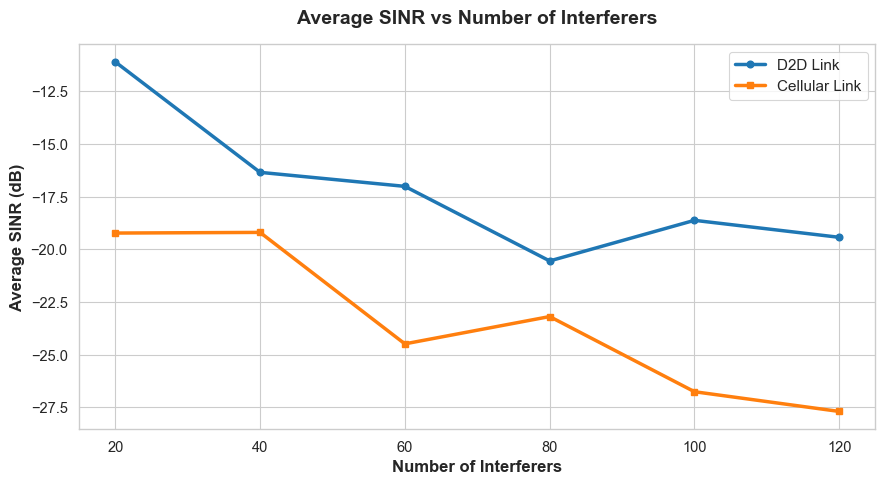

In [2]:
plt.figure(figsize=(9, 5))
plt.plot(grouped_data['num_interferers'], grouped_data['sinr_d2d_db'], marker='o', linewidth=2.5, color='#1f77b4', label='D2D Link')
plt.plot(grouped_data['num_interferers'], grouped_data['sinr_cell_db'], marker='s', linewidth=2.5, color='#ff7f0e', label='Cellular Link')

plt.title('Average SINR vs Number of Interferers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Interferers', fontsize=12, fontweight='bold')
plt.ylabel('Average SINR (dB)', fontsize=12, fontweight='bold')
plt.xticks(grouped_data['num_interferers']) # Force ticks at 20, 40, 60...
plt.legend(fontsize=11)
plt.tight_layout()

save_path_sinr = os.path.join(save_dir, 'scalability_sinr.png')
plt.savefig(save_path_sinr, dpi=300)
print(f"✓ Saved: {save_path_sinr}")
plt.show()

### Average Throughput vs Nnumber of Interferers

✓ Saved: ../results/preprocessed_proposal/scalability\scalability_throughput.png


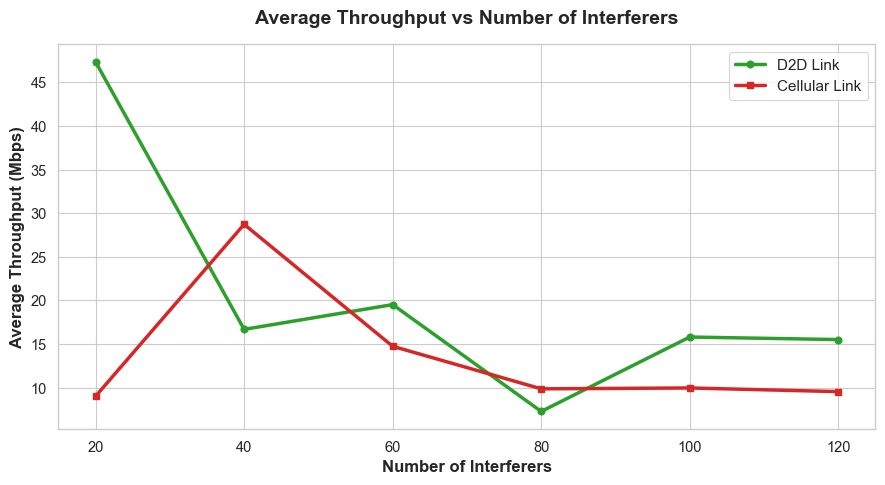

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(grouped_data['num_interferers'], grouped_data['throughput_d2d_mbps'], marker='o', linewidth=2.5, color='#2ca02c', label='D2D Link')
plt.plot(grouped_data['num_interferers'], grouped_data['throughput_cell_mbps'], marker='s', linewidth=2.5, color='#d62728', label='Cellular Link')

plt.title('Average Throughput vs Number of Interferers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Interferers', fontsize=12, fontweight='bold')
plt.ylabel('Average Throughput (Mbps)', fontsize=12, fontweight='bold')
plt.xticks(grouped_data['num_interferers'])
plt.legend(fontsize=11)
plt.tight_layout()

save_path_tput = os.path.join(save_dir, 'scalability_throughput.png')
plt.savefig(save_path_tput, dpi=300)
print(f"✓ Saved: {save_path_tput}")
plt.show()

### Rising Interference Floor

✓ Saved: ../results/preprocessed_proposal/scalability\scalability_interference.png


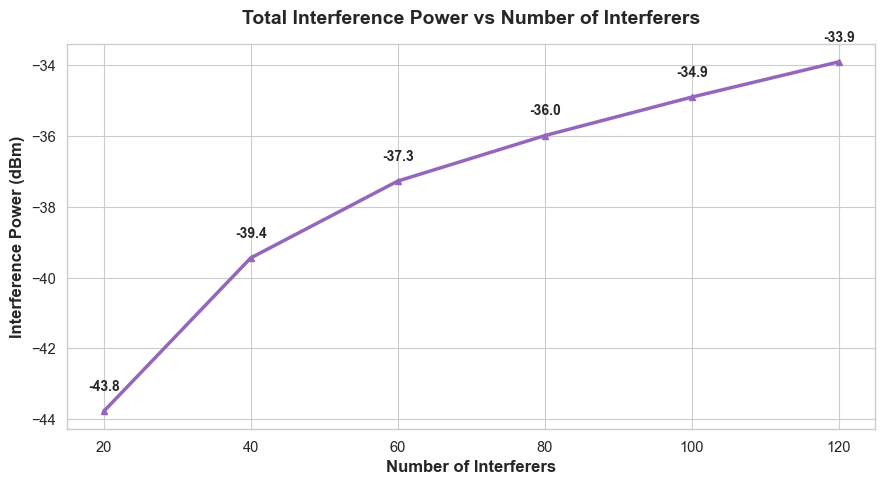

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(grouped_data['num_interferers'], grouped_data['interference_dbm'], marker='^', linewidth=2.5, color='#9467bd')

plt.title('Total Interference Power vs Number of Interferers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Interferers', fontsize=12, fontweight='bold')
plt.ylabel('Interference Power (dBm)', fontsize=12, fontweight='bold')
plt.xticks(grouped_data['num_interferers'])

# Annotate the values on the line for maximum clarity
for i in range(len(grouped_data)):
    plt.text(grouped_data['num_interferers'].iloc[i], 
             grouped_data['interference_dbm'].iloc[i] + 0.5, 
             f"{grouped_data['interference_dbm'].iloc[i]:.1f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

save_path_interf = os.path.join(save_dir, 'scalability_interference.png')
plt.savefig(save_path_interf, dpi=300)
print(f"✓ Saved: {save_path_interf}")
plt.show()